# 3B — Single-Temperature Fixed ESN Analysis

This notebook loads the deployment ESN configuration saved by Notebook 3A and runs
routine fixed-parameter regression, reservoir diagnostics, per-material error tables,
and actual-versus-predicted plots. It contains no Bayesian optimization and is safe to
rerun frequently after 3A has generated the parameter JSON file.

The nested OOF metrics from 3A remain the unbiased performance estimate. Results here
are fixed-parameter diagnostics because the configuration was selected using the full
material collection in 3A's final grouped search.


# 1. Imports and experiment configuration


In [33]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import linalg
from scipy.signal import savgol_filter
from scipy.stats import kurtosis, skew
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

#


In [34]:
FILE_TITLE = "60C"
PARAMETER_TARGET = "eff"
RANDOM_STATE = 42

cwd = Path.cwd().resolve()
project_candidates = [cwd, cwd.parent]
PROJECT_ROOT = next(
    (path for path in project_candidates if (path / "data").is_dir()), None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")

DATA_PATH = PROJECT_ROOT / "data" / "02_preprocessed" / FILE_TITLE
RESULTS_DIR = PROJECT_ROOT / "results" / "single_temp_esn"
PARAMETER_FILE = RESULTS_DIR / f"{FILE_TITLE}_{PARAMETER_TARGET}_v5_final_parameters.json"

if not DATA_PATH.is_dir():
    raise FileNotFoundError(f"Data directory not found: {DATA_PATH}")
if not PARAMETER_FILE.is_file():
    raise FileNotFoundError(
        f"Saved parameters not found: {PARAMETER_FILE}\n"
        "Run Notebook 3A to completion first."
    )

with PARAMETER_FILE.open() as file:
    SAVED_CONFIGURATION = json.load(file)

if SAVED_CONFIGURATION["file_title"] != FILE_TITLE:
    raise ValueError("Saved configuration temperature does not match FILE_TITLE.")
if SAVED_CONFIGURATION["target"] != PARAMETER_TARGET:
    raise ValueError("Saved configuration target does not match PARAMETER_TARGET.")

ANALYSIS_WINDOW = tuple(float(value) for value in SAVED_CONFIGURATION["analysis_window"])
ESN_PARAMETERS = SAVED_CONFIGURATION["esn_parameters"]
ESN_RES_SIZE = int(ESN_PARAMETERS["res_size"])
ESN_LEAK_RATE = float(ESN_PARAMETERS["leak_rate"])
ESN_INPUT_MAGNITUDE = float(ESN_PARAMETERS["input_magnitude"])
ESN_SPECTRAL_RADIUS = float(ESN_PARAMETERS["spectral_radius"])
ESN_WASHOUT = int(ESN_PARAMETERS["washout"])
XGB_PARAMS = SAVED_CONFIGURATION["xgb_parameters"]
REGRESSION_TARGETS = (PARAMETER_TARGET,)

print("Loaded:", PARAMETER_FILE)
print("Analysis window:", ANALYSIS_WINDOW)
print("ESN parameters:", ESN_PARAMETERS)
print("XGBoost parameters:", XGB_PARAMS)


Loaded: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/single_temp_esn/60C_eff_v5_final_parameters.json
Analysis window: (0.0, 5.0)
ESN parameters: {'res_size': 26, 'leak_rate': 0.15405677912001153, 'input_magnitude': 1.4425319072533664, 'spectral_radius': 0.3551351254709197, 'washout': 3}
XGBoost parameters: {'n_estimators': 224, 'max_depth': 1, 'learning_rate': 0.10958525164566212, 'min_child_weight': 14.327066349997319, 'subsample': 0.6167747796739028, 'colsample_bytree': 0.641306844958786, 'reg_alpha': 0.22173203440899703, 'reg_lambda': 13.302077544520833}


# 2. Standard material properties and trial loading

The processed CSV values in `k`, `Mass`, `Volume`, `rho`, and `cp` are deliberately
ignored. After loading the sensor data, the notebook overwrites those fields using
the authoritative table below.

`Mass=1 kg` and `Volume=1 m³` are placeholders and can be updated later.


In [35]:
STANDARD_PROPERTIES = {
    "ps_foam":   {"k": 0.034, "Mass": 1.0, "Volume": 1.0, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":   {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 30.0,   "cp": 1400.0},
    "cork":      {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 240.0,  "cp": 1800.0},
    "wood":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 700.0,  "cp": 1700.0},
    "pdms":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 970.0,  "cp": 1460.0},
    "gypsum":    {"k": 0.170, "Mass": 1.0, "Volume": 1.0, "rho": 800.0,  "cp": 1090.0},
    "cement":    {"k": 0.290, "Mass": 1.0, "Volume": 1.0, "rho": 1440.0, "cp": 750.0},
    "graphite":  {"k": 100.0, "Mass": 1.0, "Volume": 1.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":   {"k": 8.1,   "Mass": 1.0, "Volume": 1.0, "rho": 9780.0, "cp": 130.0},
    "titanium":  {"k": 21.9,  "Mass": 1.0, "Volume": 1.0, "rho": 4506.0, "cp": 523.0},
    "nickel":    {"k": 90.9,  "Mass": 1.0, "Volume": 1.0, "rho": 8908.0, "cp": 461.0},
    "iron":      {"k": 80.4,  "Mass": 1.0, "Volume": 1.0, "rho": 7874.0, "cp": 449.0},
    "aluminum":  {"k": 237.0, "Mass": 1.0, "Volume": 1.0, "rho": 2700.0, "cp": 897.0},
    "copper":    {"k": 401.0, "Mass": 1.0, "Volume": 1.0, "rho": 8960.0, "cp": 385.0},
}

SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood",
    "pdms": "pdms",
    "gypsum": "gypsum",
    "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

standard_table = (
    pd.DataFrame.from_dict(STANDARD_PROPERTIES, orient="index")
    .rename_axis("Material")
    .reset_index()
)
display(standard_table)

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []

for path in sorted(DATA_PATH.glob("*.csv")):
    frame = pd.read_csv(path)
    missing = required - set(frame.columns)
    if missing:
        warnings.warn(f"Skipping {path.name}; missing {sorted(missing)}")
        continue
    frames.append(frame)

if not frames:
    raise ValueError("No valid trial files were found.")

DATA = pd.concat(frames, ignore_index=True)
DATA = DATA.replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required)).copy()
DATA["Trial"] = DATA["Trial"].astype(int)

normalized_sample = (
    DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
)
DATA["Sample"] = normalized_sample.map(SAMPLE_ALIASES)
unknown_mask = DATA["Sample"].isna()
if unknown_mask.any():
    unknown = sorted(normalized_sample[unknown_mask].unique())
    raise KeyError(f"No standard-property mapping for samples: {unknown}")

# Overwrite processed-file properties unconditionally.
for property_name in ("k", "Mass", "Volume", "rho", "cp"):
    DATA[property_name] = DATA["Sample"].map(
        lambda sample: STANDARD_PROPERTIES[sample][property_name]
    )

DATA["trial_id"] = (
    DATA["Sample"].astype(str) + "_trial_" + DATA["Trial"].astype(str)
)
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)

# Literature k should be stable by material. Density may vary across measured
# specimens/trials, so the derived eff target is allowed to vary by trial.
k_counts = DATA.groupby("Sample")["k"].nunique()
if (k_counts != 1).any():
    raise ValueError(
        f"k is not constant within: {k_counts[k_counts != 1].index.tolist()}"
    )

summary = (
    DATA.groupby(["trial_id", "Sample", "Trial"], as_index=False)
    .agg(
        n_timesteps=("Time", "size"),
        k=("k", "first"),
        eff=("eff", "first"),
    )
)
print(f"Rows: {len(DATA):,}")
print(f"Trials: {DATA['trial_id'].nunique()}")
print(f"Independent materials: {DATA['Sample'].nunique()}")
display(summary.head())


,Material,k,Mass,Volume,rho,cp
0,ps_foam,0.034,1.0,1.0,25.0,1400.0
1,pu_foam,0.043,1.0,1.0,30.0,1400.0
2,cork,0.043,1.0,1.0,240.0,1800.0
3,wood,0.150,1.0,1.0,700.0,1700.0
4,pdms,0.150,1.0,1.0,970.0,1460.0
5,gypsum,0.170,1.0,1.0,800.0,1090.0
6,cement,0.290,1.0,1.0,1440.0,750.0
7,graphite,100.000,1.0,1.0,1820.0,710.0
8,bismuth,8.100,1.0,1.0,9780.0,130.0
9,titanium,21.900,1.0,1.0,4506.0,523.0


Rows: 17,328
Trials: 84
Independent materials: 14


,trial_id,Sample,Trial,n_timesteps,k,eff
0,aluminum_trial_1,aluminum,1,210,237.0,23958.094665
1,aluminum_trial_2,aluminum,2,230,237.0,23958.094665
2,aluminum_trial_3,aluminum,3,194,237.0,23958.094665
3,aluminum_trial_4,aluminum,4,200,237.0,23958.094665
4,aluminum_trial_5,aluminum,5,210,237.0,23958.094665


# 3. Detect contact and align every trial

The elbow is used only to establish a common time origin. Prediction uses the fixed
0–5 second response after contact. Trials are never aligned using `k` or `eff`.


In [36]:
def find_contact_time(
    trial,
    smooth_window=15,
    polyorder=2,
    threshold_frac=0.30,
    skip_samples=5,
):
    clean = (
        trial[["Time", "Primary"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates("Time")
        .reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid time samples.")

    work_time = time[skip_samples:]
    work_signal = signal[skip_samples:]
    window = min(int(smooth_window), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    if window < minimum:
        raise ValueError("Sequence is too short for smoothing.")

    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])

In [37]:
aligned_trials = {}
alignment_rows = []

for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact_time = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue

    trial["time_from_contact"] = trial["Time"] - contact_time
    start, end = ANALYSIS_WINDOW
    trial = trial[
        trial["time_from_contact"].between(start, end, inclusive="both")
    ].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: too few post-contact samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    alignment_rows.append({
        "trial_id": trial_id,
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "contact_time": contact_time,
        "n_analysis_samples": len(trial),
    })

ALIGNMENT = pd.DataFrame(alignment_rows)
print(f"Aligned trials retained: {len(aligned_trials)}")
display(ALIGNMENT.head())

Aligned trials retained: 84


,trial_id,Sample,Trial,contact_time,n_analysis_samples
0,aluminum_trial_1,aluminum,1,9.40070,51
1,aluminum_trial_2,aluminum,2,10.90066,50
2,aluminum_trial_3,aluminum,3,8.10070,51
3,aluminum_trial_4,aluminum,4,7.80070,51
4,aluminum_trial_5,aluminum,5,9.00067,50


## Check several alignments visually


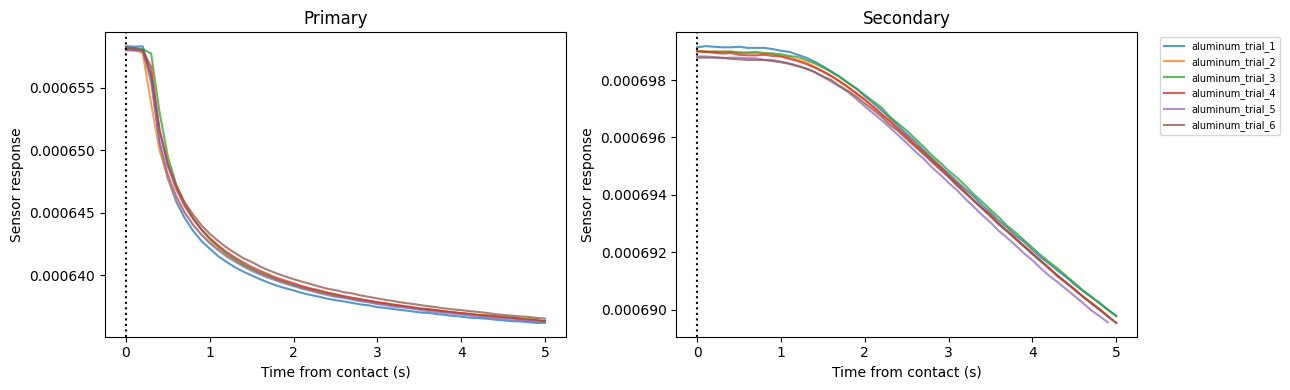

In [38]:
def plot_aligned_trials(material=None, maximum_trials=6):
    selected = list(aligned_trials.values())
    if material is not None:
        selected = [x for x in selected if x["Sample"].iloc[0] == material]
    selected = selected[:maximum_trials]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for trial in selected:
        label = trial["trial_id"].iloc[0]
        axes[0].plot(trial["time_from_contact"], trial["Primary"], alpha=0.75, label=label)
        axes[1].plot(trial["time_from_contact"], trial["Secondary"], alpha=0.75, label=label)
    for ax, title in zip(axes, ["Primary", "Secondary"]):
        ax.axvline(0, color="black", linestyle=":")
        ax.set(xlabel="Time from contact (s)", ylabel="Sensor response", title=title)
    axes[1].legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_aligned_trials(material=ALIGNMENT["Sample"].iloc[0])

# 4. Interpretable thermal-response features

Because the analysis interval is 0–5 s, every feature summarizes the complete
transient. The interval is not subdivided into early, middle, and late windows.


In [39]:
def _smooth(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= minimum else values.copy()
    )


def _response_slope(time, values):
    valid = np.isfinite(time) & np.isfinite(values)
    if valid.sum() < 3:
        return np.nan
    return float(np.polyfit(time[valid], values[valid], 1)[0])


def extract_thermal_features(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    result = {}

    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time)
        result[f"{name}_final_change"] = float(change[-1])
        result[f"{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"{name}_response_auc"] = float(np.trapezoid(np.abs(change), time))
        result[f"{name}_response_slope"] = _response_slope(time, signal)
        result[f"{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time))

    # Dimensionless/cross-sensor summaries.
    primary_auc = result["primary_response_auc"]
    result["secondary_primary_auc_ratio"] = (
        result["secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["initial_sensor_difference"] = float(difference[0])
    result["final_sensor_difference"] = float(difference[-1])
    return result


thermal_rows = []
for trial_id, trial in aligned_trials.items():
    features = extract_thermal_features(trial)
    features.update({
        "trial_id": trial_id,
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "k": float(trial["k"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })
    thermal_rows.append(features)

THERMAL_FEATURES = pd.DataFrame(thermal_rows)
print(f"Thermal features: {len(THERMAL_FEATURES.columns) - 5}")
display(THERMAL_FEATURES.head())


Thermal features: 21


,primary_final_change,primary_max_abs_change,primary_response_auc,primary_response_slope,primary_max_abs_rate,primary_rate_auc,secondary_final_change,secondary_max_abs_change,secondary_response_auc,secondary_response_slope,...,difference_max_abs_rate,difference_rate_auc,secondary_primary_auc_ratio,initial_sensor_difference,final_sensor_difference,trial_id,Sample,Trial,k,eff
0,-0.000025,0.000025,0.000102,-0.000003,0.000026,0.000025,-0.000009,0.000009,0.000018,-0.000002,...,0.000026,0.000025,0.173943,-0.000038,-0.000054,aluminum_trial_1,aluminum,1,237.0,23958.094665
1,-0.000024,0.000024,0.000096,-0.000003,0.000027,0.000024,-0.000009,0.000009,0.000017,-0.000002,...,0.000027,0.000024,0.176338,-0.000039,-0.000053,aluminum_trial_2,aluminum,2,237.0,23958.094665
2,-0.000024,0.000024,0.000098,-0.000003,0.000024,0.000024,-0.000009,0.000009,0.000017,-0.000002,...,0.000024,0.000024,0.174287,-0.000039,-0.000053,aluminum_trial_3,aluminum,3,237.0,23958.094665
3,-0.000024,0.000024,0.000097,-0.000003,0.000022,0.000024,-0.000009,0.000009,0.000018,-0.000002,...,0.000022,0.000024,0.183508,-0.000039,-0.000053,aluminum_trial_4,aluminum,4,237.0,23958.094665
4,-0.000024,0.000024,0.000096,-0.000003,0.000024,0.000024,-0.000009,0.000009,0.000017,-0.000002,...,0.000024,0.000024,0.176910,-0.000039,-0.000053,aluminum_trial_5,aluminum,5,237.0,23958.094665


# 5. Manual ESN reservoir and compact trajectory summaries

For every trial, the reservoir produces a time-by-unit state matrix. This version
does **not** flatten the raw states. Instead, it describes every reservoir-unit
trajectory with nine complementary summaries:

- mean and standard deviation: activation level and variability
- range: peak-to-peak activation magnitude
- net change and linear slope: endpoint change and overall direction
- absolute area: accumulated activation magnitude
- time of maximum absolute activation: timing of the strongest response
- skewness and excess kurtosis: trajectory-distribution shape

Thus, a reservoir with `r` units produces `9 × r` predictors per trial. Removed
summaries were exact or strong proxies of retained quantities over a common time
window (for example, initial/final versus net change; min/max versus range; signed
area versus mean; and mean absolute activation versus absolute area). Time is
retained indirectly through slope, absolute area, peak timing, and net change. Input
scaling is fitted inside each outer training fold.


In [40]:
class ManualReservoir:
    def __init__(
        self,
        res_size=30,
        leak_rate=0.9,
        input_magnitude=1.5,
        spectral_radius=1.3,
        washout=0,
        random_state=42,
    ):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.input_magnitude = float(input_magnitude)
        self.spectral_radius = float(spectral_radius)
        self.washout = int(washout)
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 1 + 5)) - 0.5) * self.input_magnitude
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * self.spectral_radius

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 5:
            raise ValueError("Expected sequence with five input channels.")
        if len(sequence) <= self.washout:
            raise ValueError(
                f"Sequence has {len(sequence)} samples, but washout={self.washout}. "
                "Washout must be smaller than the sequence length."
            )
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            u = row.reshape(-1, 1)
            x = (
                (1 - self.leak_rate) * x
                + self.leak_rate * np.tanh(
                    self.Win @ np.vstack((1.0, u)) + self.W @ x
                )
            )
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]


def raw_esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    primary_rate = np.gradient(primary, time)
    secondary_rate = np.gradient(secondary, time)
    return np.column_stack([
        primary, secondary, difference, primary_rate, secondary_rate
    ])


def summarize_reservoir_trajectories(time, states):
    """Return finite statistical/dynamical summaries for every reservoir unit."""
    time = np.asarray(time, float)
    states = np.asarray(states, float)
    if states.ndim != 2 or len(time) != len(states):
        raise ValueError("Time and reservoir states must have matching rows.")
    if len(time) < 2 or np.any(~np.isfinite(time)) or np.any(np.diff(time) <= 0):
        raise ValueError("Reservoir-state time must be finite and strictly increasing.")
    if np.any(~np.isfinite(states)):
        raise ValueError("Reservoir states contain non-finite values.")

    result = {}
    for unit in range(states.shape[1]):
        values = states[:, unit]
        maximum_absolute_index = int(np.argmax(np.abs(values)))
        standard_deviation = float(np.std(values, ddof=0))

        # Constant or nearly constant trajectories have well-defined zero shape
        # rather than scipy's otherwise undefined skewness/kurtosis warnings.
        if len(values) < 3 or np.isclose(standard_deviation, 0.0):
            skewness = 0.0
        else:
            skewness = float(skew(values, bias=False))
        if len(values) < 4 or np.isclose(standard_deviation, 0.0):
            excess_kurtosis = 0.0
        else:
            excess_kurtosis = float(kurtosis(values, fisher=True, bias=False))

        summaries = {
            "mean": float(np.mean(values)),
            "std": standard_deviation,
            "range": float(np.ptp(values)),
            "net_change": float(values[-1] - values[0]),
            "slope": float(np.polyfit(time, values, 1)[0]),
            "absolute_area": float(np.trapezoid(np.abs(values), time)),
            "time_of_max_absolute": float(time[maximum_absolute_index]),
            "skewness": skewness,
            "excess_kurtosis": excess_kurtosis,
        }
        
        for name, value in summaries.items():
            if not np.isfinite(value):
                raise ValueError(f"Non-finite {name} for reservoir unit {unit}.")
            result[f"esn_{name}_u{unit:03d}"] = value
    return result


# 6. Visualize ESN state evolution

This section shows how the reservoir responds through the 0–5 second post-contact
window. The visualization uses the same reservoir hyperparameters as regression.

The scaler below is fitted across all trials **only for descriptive visualization**.
It is not reused by cross-validation; evaluation continues to fit scaling exclusively
inside each outer training fold.


In [41]:
def compute_visualization_states(trial_id):
    if trial_id not in aligned_trials:
        raise KeyError(trial_id)

    # Descriptive scaler only—never passed into the evaluation engine.
    visualization_scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(trial) for trial in aligned_trials.values()
    ]))
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE,
        leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS,
        washout=ESN_WASHOUT,
        random_state=RANDOM_STATE,
    )
    trial = aligned_trials[trial_id]
    scaled_sequence = visualization_scaler.transform(raw_esn_input(trial))
    states = reservoir.run(scaled_sequence)
    time = trial["time_from_contact"].to_numpy(float)[ESN_WASHOUT:]
    return trial, time, scaled_sequence[ESN_WASHOUT:], states


SELECTED_TRIAL_ID = ALIGNMENT["trial_id"].iloc[0]
selected_trial, state_time, selected_inputs, selected_states = (
    compute_visualization_states(SELECTED_TRIAL_ID)
)

print("Selected trial:", SELECTED_TRIAL_ID)
print("Reservoir-state matrix:", selected_states.shape)


Selected trial: aluminum_trial_1
Reservoir-state matrix: (48, 26)


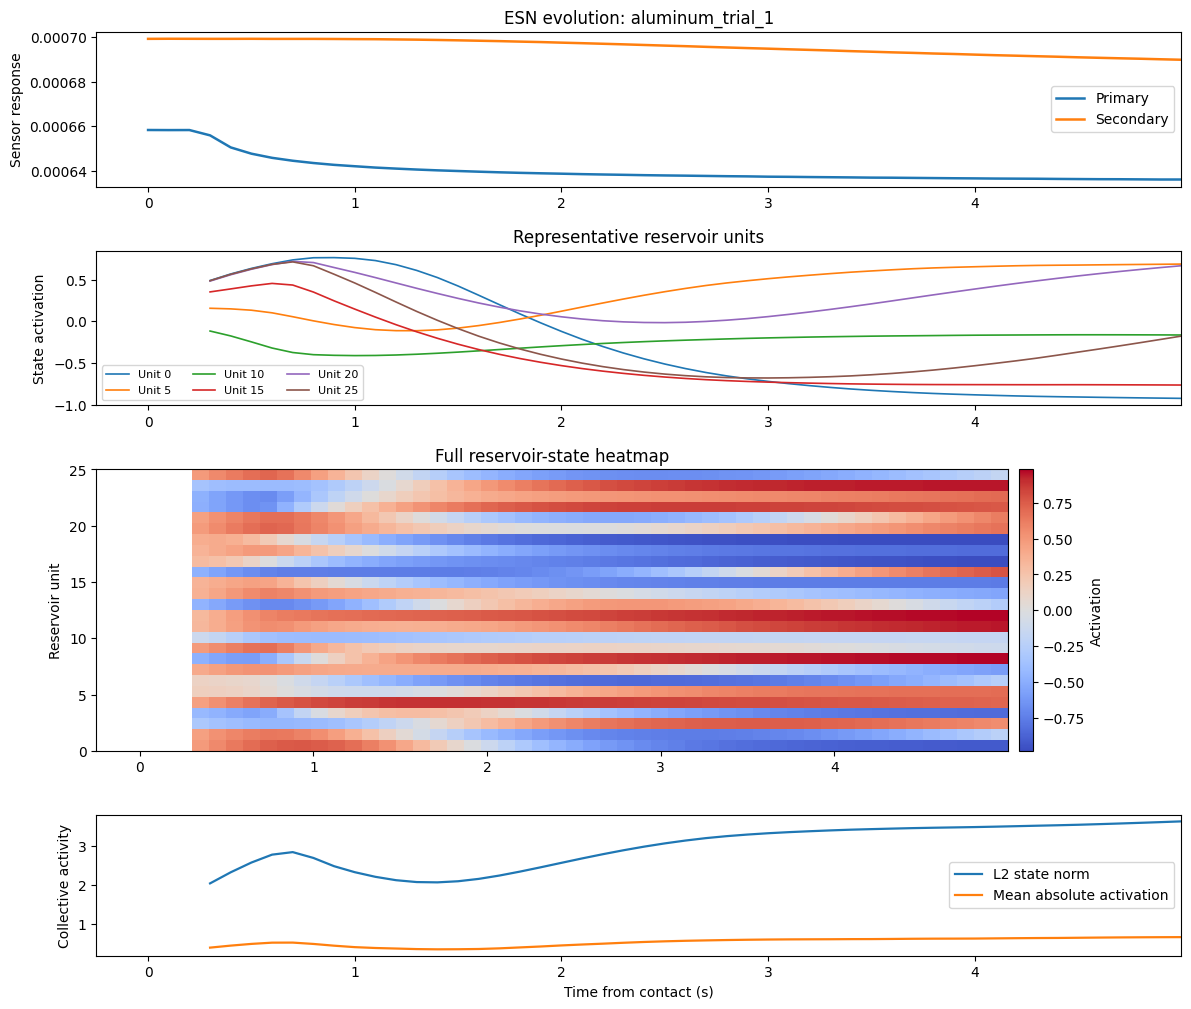

In [42]:
def plot_esn_dynamics(trial_id=SELECTED_TRIAL_ID, units_to_plot=(0, 5, 10, 15, 20, 25)):
    trial, time, scaled_inputs, states = compute_visualization_states(trial_id)

    fig = plt.figure(figsize=(14, 12))
    grid = fig.add_gridspec(4, 1, height_ratios=[1.1, 1.1, 2.0, 1.0], hspace=0.35)

    # Raw sensor response
    ax_inputs = fig.add_subplot(grid[0])
    ax_inputs.plot(
        trial["time_from_contact"], trial["Primary"],
        label="Primary", linewidth=1.8,
    )
    ax_inputs.plot(
        trial["time_from_contact"], trial["Secondary"],
        label="Secondary", linewidth=1.8,
    )
    ax_inputs.set(ylabel="Sensor response", title=f"ESN evolution: {trial_id}")
    ax_inputs.legend(loc="best")

    # Representative reservoir units
    ax_units = fig.add_subplot(grid[1], sharex=ax_inputs)
    valid_units = [unit for unit in units_to_plot if unit < states.shape[1]]
    for unit in valid_units:
        ax_units.plot(time, states[:, unit], label=f"Unit {unit}", linewidth=1.2)
    ax_units.set(ylabel="State activation", title="Representative reservoir units")
    ax_units.legend(ncol=3, fontsize=8)

    # Full state heatmap
    ax_heatmap = fig.add_subplot(grid[2], sharex=ax_inputs)
    limit = np.max(np.abs(states))
    image = ax_heatmap.imshow(
        states.T,
        aspect="auto",
        origin="lower",
        extent=[time.min(), time.max(), 0, states.shape[1] - 1],
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        interpolation="nearest",
    )
    ax_heatmap.set(ylabel="Reservoir unit", title="Full reservoir-state heatmap")
    fig.colorbar(image, ax=ax_heatmap, label="Activation", pad=0.01)

    # Collective reservoir activity
    ax_norm = fig.add_subplot(grid[3], sharex=ax_inputs)
    state_norm = np.linalg.norm(states, axis=1)
    mean_abs_state = np.mean(np.abs(states), axis=1)
    ax_norm.plot(time, state_norm, label="L2 state norm", linewidth=1.6)
    ax_norm.plot(time, mean_abs_state, label="Mean absolute activation", linewidth=1.6)
    ax_norm.set(xlabel="Time from contact (s)", ylabel="Collective activity")
    ax_norm.legend(loc="best")

    plt.show()


plot_esn_dynamics()


## How to interpret the dynamics

- Each heatmap row is one reservoir unit and each column is a post-contact timestep.
- Alternating red and blue patterns show nonlinear units responding with different signs.
- Persistent bands indicate memory of earlier sensor behavior.
- Rapid changes shortly after contact show the reservoir encoding the transient response.
- The state norm summarizes the strength of collective reservoir activation.
- These states are not predictions by themselves; their trajectory summaries become the ESN regression features.


# 7. Leakage-safe XGBoost regression and valid metrics

For LORO and inner material-grouped validation folds, several target values are
present and ordinary R²/NRMSE-range are defined. A single outer LOMO fold contains
only one held-out material, so its target is constant: fold-level R² and test-range
NRMSE are mathematically undefined and are not reported.

LOMO outer folds instead report MAE, RMSE, bias, median APE, and RMSE normalized by
the **outer-training target range**. Overall R² and NRMSE are computed once from all
pooled out-of-fold material predictions.


In [43]:
def regression_metrics(y_true, y_pred):
    """Metrics requiring variation in y_true; intended for pooled or mixed-target data."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) == 0 or np.any(~np.isfinite(y_true)) or np.any(~np.isfinite(y_pred)):
        raise ValueError("Metrics require non-empty, finite targets and predictions.")
    target_range = float(np.ptp(y_true))
    if len(y_true) < 2 or target_range <= 0:
        raise ValueError(
            "R² and test-range NRMSE require at least two distinct target values. "
            "Use constant_target_fold_metrics for a single-material LOMO fold."
        )
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "n": len(y_true),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range,
        "r2": float(r2_score(y_true, y_pred)),
        "median_ape_pct": float(np.median(np.abs((y_true - y_pred) / y_true)) * 100),
    }


def constant_target_fold_metrics(y_true, y_pred, training_target_range):
    """Valid diagnostics for one outer LOMO fold with a constant test target."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    training_target_range = float(training_target_range)
    if len(y_true) == 0 or np.any(~np.isfinite(y_true)) or np.any(~np.isfinite(y_pred)):
        raise ValueError("Fold metrics require non-empty, finite values.")
    if training_target_range <= 0:
        raise ValueError("The outer-training target range must be positive.")
    residual = y_pred - y_true
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    return {
        "n": len(y_true),
        "mae": float(np.mean(np.abs(residual))),
        "rmse": rmse,
        "nrmse_training_range": rmse / training_target_range,
        "mean_error_bias": float(np.mean(residual)),
        "median_ape_pct": float(np.median(np.abs(residual / y_true)) * 100),
    }


def make_regressor(xgb_params=None, random_state=RANDOM_STATE):
    params = {**XGB_PARAMS, **(xgb_params or {})}
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=int(random_state),
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        **params,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


# 8. XGBoost evaluation engine


In [44]:
def outer_splits(table, protocol):
    if protocol == "held_out_repetition":
        splitter = GroupKFold(n_splits=table["Trial"].nunique())
        return splitter.split(table, groups=table["Trial"])
    if protocol == "held_out_material":
        splitter = LeaveOneGroupOut()
        return splitter.split(table, groups=table["Sample"])
    raise ValueError("Unknown protocol.")


def build_esn_feature_table(train_ids, all_ids, esn_params=None, random_state=RANDOM_STATE):
    params = {
        "res_size": ESN_RES_SIZE,
        "leak_rate": ESN_LEAK_RATE,
        "input_magnitude": ESN_INPUT_MAGNITUDE,
        "spectral_radius": ESN_SPECTRAL_RADIUS,
        "washout": ESN_WASHOUT,
    }
    params.update(esn_params or {})
    scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(aligned_trials[trial_id]) for trial_id in train_ids
    ]))
    reservoir = ManualReservoir(**params, random_state=random_state)
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        sequence = scaler.transform(raw_esn_input(trial))
        states = reservoir.run(sequence)
        state_time = trial["time_from_contact"].to_numpy(float)[params["washout"]:]
        features = summarize_reservoir_trajectories(state_time, states)
        features.update({
            "trial_id": trial_id,
            "Sample": trial["Sample"].iloc[0],
            "Trial": int(trial["Trial"].iloc[0]),
            "k": float(trial["k"].iloc[0]),
            "eff": float(trial["eff"].iloc[0]),
        })
        rows.append(features)
    return pd.DataFrame(rows)


def evaluate_feature_family(feature_family, target, protocol):
    metadata = THERMAL_FEATURES[["trial_id", "Sample", "Trial", "k", "eff"]].copy()
    fold_rows, prediction_rows = [], []

    for fold, (train_idx, test_idx) in enumerate(outer_splits(metadata, protocol), start=1):
        train_meta = metadata.iloc[train_idx]
        test_meta = metadata.iloc[test_idx]
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()

        if set(train_ids) & set(test_ids):
            raise RuntimeError("Trial leakage detected.")
        if protocol == "held_out_material" and set(train_meta["Sample"]) & set(test_meta["Sample"]):
            raise RuntimeError("Material leakage detected.")

        if feature_family == "thermal":
            fold_features = THERMAL_FEATURES
        elif feature_family == "esn":
            fold_features = build_esn_feature_table(train_ids, train_ids + test_ids)
        else:
            raise ValueError("feature_family must be thermal or esn")

        indexed = fold_features.set_index("trial_id")
        excluded = {"Sample", "Trial", "k", "eff"}
        feature_cols = [
            c for c in fold_features.select_dtypes(include=np.number).columns
            if c not in excluded
        ]
        X_train = indexed.loc[train_ids, feature_cols].reset_index(drop=True)
        X_test = indexed.loc[test_ids, feature_cols].reset_index(drop=True)
        y_train = indexed.loc[train_ids, target].reset_index(drop=True)
        y_test = indexed.loc[test_ids, target].reset_index(drop=True)

        model = make_regressor()
        model.fit(X_train, y_train)
        pred = np.clip(model.predict(X_test), y_train.min(), y_train.max())

        if protocol == "held_out_material":
            fold_diagnostics = constant_target_fold_metrics(
                y_test, pred, np.ptp(y_train.to_numpy(float))
            )
        else:
            fold_diagnostics = regression_metrics(y_test, pred)
        fold_rows.append({
            "fold": fold,
            "feature_family": feature_family,
            "target": target,
            "protocol": protocol,
            "test_materials": ", ".join(sorted(set(test_meta["Sample"]))),
            **fold_diagnostics,
        })
        prediction_rows.append(pd.DataFrame({
            "trial_id": test_ids,
            "Sample": test_meta["Sample"].to_numpy(),
            "Trial": test_meta["Trial"].to_numpy(),
            "fold": fold,
            "y_true": y_test,
            "y_pred": pred,
        }))

    fold_metrics = pd.DataFrame(fold_rows)
    predictions = pd.concat(prediction_rows, ignore_index=True)
    overall = pd.DataFrame([{
        "feature_family": feature_family,
        "target": target,
        "protocol": protocol,
        **regression_metrics(predictions["y_true"], predictions["y_pred"]),
    }])
    return fold_metrics, overall, predictions


# 9. Fixed Temperature: held-out repetitions

This protocol tests a new experimental repetition while other trials of the same
materials remain in training. It is the appropriate primary measure of repeatability.


In [45]:
repetition_results = []
repetition_predictions = {}

for family in ("thermal", "esn"):
    for target in REGRESSION_TARGETS:
        folds, overall, predictions = evaluate_feature_family(
            family, target, "held_out_repetition"
        )
        repetition_results.append(overall)
        repetition_predictions[(family, target)] = predictions

REPETITION_RESULTS = pd.concat(repetition_results, ignore_index=True)
display(REPETITION_RESULTS)


,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,eff,held_out_repetition,84,2391.042156,4857.154263,0.130716,0.812202,27.589038
1,esn,eff,held_out_repetition,84,2750.690114,4949.155522,0.133192,0.805020,25.021476


# 10. Fixed Temperature: held-out materials

Each material is predicted only by a model trained without that material. The main
LOMO R²/NRMSE values are pooled out-of-fold metrics. Per-fold diagnostics are shown
separately to reveal whether a good pooled score hides failures on specific materials.


In [46]:
material_results = []
material_predictions = {}
material_fold_metrics = {}

for family in ("thermal", "esn"):
    for target in REGRESSION_TARGETS:
        folds, overall, predicted = evaluate_feature_family(
            family, target, "held_out_material"
        )
        material_results.append(overall)
        material_predictions[(family, target)] = predicted
        material_fold_metrics[(family, target)] = folds

MATERIAL_RESULTS = pd.concat(material_results, ignore_index=True)
print("Pooled out-of-fold LOMO performance:")
display(MATERIAL_RESULTS)

# Every value below is defined: R² and test-range NRMSE are intentionally absent.
LOMO_PER_FOLD_RESULTS = pd.concat(
    [table for table in material_fold_metrics.values()], ignore_index=True
)
print("Per-material LOMO diagnostics:")
display(LOMO_PER_FOLD_RESULTS.sort_values(
    ["target", "feature_family", "rmse"], ascending=[True, True, False]
))

LOMO_FOLD_STABILITY = (
    LOMO_PER_FOLD_RESULTS
    .groupby(["feature_family", "target", "protocol"], as_index=False)
    .agg(
        folds=("fold", "count"),
        mean_fold_mae=("mae", "mean"),
        sd_fold_mae=("mae", "std"),
        worst_fold_mae=("mae", "max"),
        mean_fold_rmse=("rmse", "mean"),
        sd_fold_rmse=("rmse", "std"),
        worst_fold_rmse=("rmse", "max"),
        mean_fold_nrmse_training_range=("nrmse_training_range", "mean"),
        sd_fold_nrmse_training_range=("nrmse_training_range", "std"),
        worst_fold_nrmse_training_range=("nrmse_training_range", "max"),
    )
)
print("Across-material fold stability summary:")
display(LOMO_FOLD_STABILITY)


Pooled out-of-fold LOMO performance:


,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,eff,held_out_material,84,3159.868881,5885.486820,0.158390,0.724264,49.010549
1,esn,eff,held_out_material,84,3718.278371,6789.796929,0.182727,0.633021,54.338375


Per-material LOMO diagnostics:


,fold,feature_family,target,protocol,test_materials,n,mae,rmse,nrmse_training_range,mean_error_bias,median_ape_pct
17,4,esn,eff,held_out_material,copper,6,20696.001317,20885.609275,0.873013,-20696.001317,57.098689
14,1,esn,eff,held_out_material,aluminum,6,7902.933858,8464.190069,0.227789,-7902.933858,34.694267
26,13,esn,eff,held_out_material,titanium,6,7454.237511,7664.272824,0.206261,7454.237511,104.928060
21,8,esn,eff,held_out_material,iron,6,5453.570420,5927.563890,0.159523,4464.924803,28.152662
22,9,esn,eff,held_out_material,nickel,6,5008.032741,5599.632614,0.150697,605.565672,22.364531
19,6,esn,eff,held_out_material,graphite,6,2302.692068,2782.866628,0.074893,714.322298,19.949233
15,2,esn,eff,held_out_material,bismuth,6,2054.573951,2056.033579,0.055332,-2054.573951,63.249255
16,3,esn,eff,held_out_material,cement,6,468.665505,478.275518,0.012871,468.665505,82.481621
23,10,esn,eff,held_out_material,pdms,6,245.757912,250.885272,0.006752,-245.757912,54.338375
27,14,esn,eff,held_out_material,wood,6,226.145174,228.606264,0.006152,-226.145174,51.442082


Across-material fold stability summary:


,feature_family,target,protocol,folds,mean_fold_mae,sd_fold_mae,worst_fold_mae,mean_fold_rmse,sd_fold_rmse,worst_fold_rmse,mean_fold_nrmse_training_range,sd_fold_nrmse_training_range,worst_fold_nrmse_training_range
0,esn,eff,held_out_material,14,3718.278371,5666.908746,20696.001317,3900.717453,5767.284654,20885.609275,0.127186,0.229917,0.873013
1,thermal,eff,held_out_material,14,3159.868881,5066.258064,18626.801936,3253.603133,5089.523967,18645.864689,0.107389,0.204830,0.779392


# 11. Compare actual and predicted values


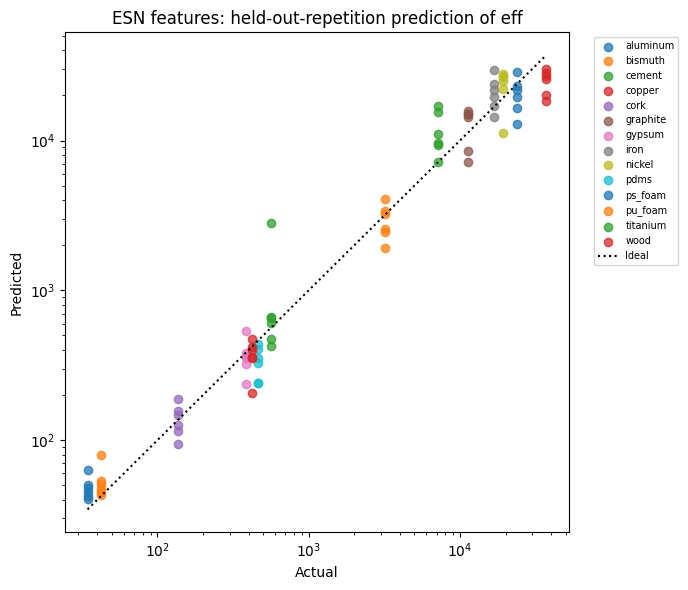

In [47]:
def plot_actual_predicted(predictions, title):
    positive = (predictions["y_true"] > 0) & (predictions["y_pred"] > 0)
    shown = predictions[positive]
    fig, ax = plt.subplots(figsize=(7, 6))
    for material, part in shown.groupby("Sample"):
        ax.scatter(part["y_true"], part["y_pred"], label=material, alpha=0.75)
    low = min(shown["y_true"].min(), shown["y_pred"].min())
    high = max(shown["y_true"].max(), shown["y_pred"].max())
    ax.plot([low, high], [low, high], color="black", linestyle=":", label="Ideal")
    ax.set(xscale="log", yscale="log", xlabel="Actual", ylabel="Predicted", title=title)
    ax.legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    fig.tight_layout()
    plt.show()


for target in REGRESSION_TARGETS:
    plot_actual_predicted(
        repetition_predictions[("esn", target)],
        f"ESN features: held-out-repetition prediction of {target}",
    )


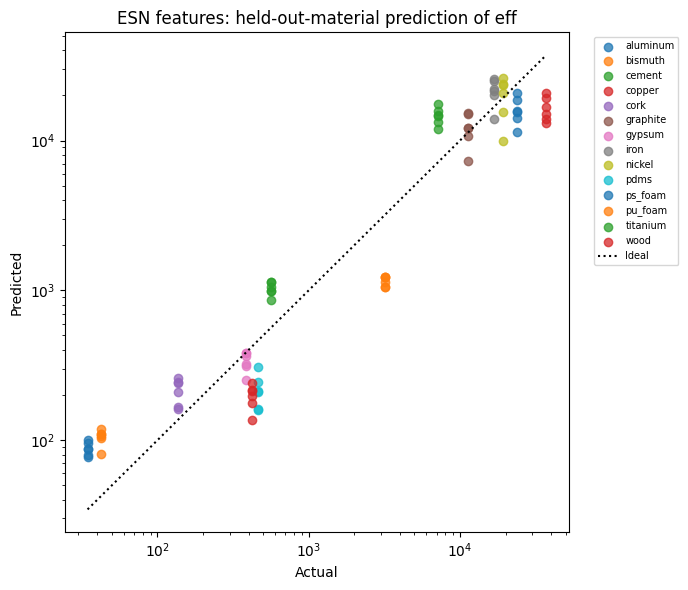

In [48]:
for target in REGRESSION_TARGETS:
    plot_actual_predicted(
        material_predictions[("esn", target)],
        f"ESN features: held-out-material prediction of {target}",
    )


# 12. Interpretation and provenance

- Parameters are loaded from 3A; no optimization occurs in this notebook.
- The loaded ESN configuration is target-specific and should not automatically be reused for another target.
- Fixed-parameter LORO and LOMO results are useful diagnostics and visualizations.
- The nested outer OOF metrics saved by 3A are the primary unbiased performance estimate.
- Per-material LOMO R² is undefined; use the valid error and stability tables provided here.
